##### 1 input, 1 output

In [45]:
from sklearn.linear_model import LinearRegression,LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [46]:
df=pd.read_csv("https://raw.githubusercontent.com/Arannamoy/datasets/refs/heads/main/Weight%20Height/height_weight_dataset_100k.csv")

In [47]:
df.head(5)

,Height_cm,Weight_kg,Gender
0,164.3,57.2,Female
1,168.4,71.4,Female
2,177.4,80.2,Male
3,166.6,64.9,Female
4,160.8,59.7,Female


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Height_cm  100000 non-null  float64
 1   Weight_kg  100000 non-null  float64
 2   Gender     100000 non-null  str    
dtypes: float64(2), str(1)
memory usage: 2.8 MB


In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train,X_test,y_train,y_test=train_test_split(df["Weight_kg"],df["Height_cm"],random_state=42)

In [51]:
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [52]:
scaler=StandardScaler()

In [53]:
X_train.info()

<class 'pandas.Series'>
Index: 75000 entries, 98980 to 15795
Series name: Weight_kg
Non-Null Count  Dtype  
--------------  -----  
75000 non-null  float64
dtypes: float64(1)
memory usage: 1.1 MB


In [54]:
X_train=scaler.fit_transform(pd.DataFrame(X_train))
X_test=scaler.transform(pd.DataFrame(X_test))

In [55]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
from sklearn.metrics import r2_score

In [57]:
score=r2_score(y_test,lr.predict(X_test))

In [58]:
score

0.6470163328184699

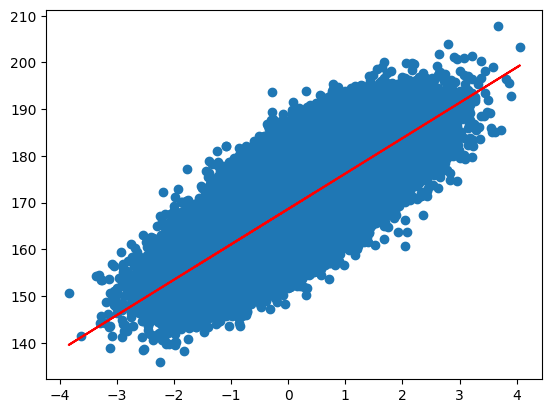

In [59]:
plt.scatter(X_train,y_train)
plt.plot(X_train,lr.predict(X_train),color="red")

In [60]:
import statsmodels.api as sm

In [61]:
lr_1=sm.OLS(y_train,X_train).fit()

In [62]:
lr_1.predict(X_test)

array([  9.60362687,   4.3945137 , -12.72114384, ...,  -0.44251995,
        -2.11687775,   4.82860647], shape=(25000,))

In [63]:
lr_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:              Height_cm   R-squared (uncentered):                   0.002
Model:                            OLS   Adj. R-squared (uncentered):              0.002
Method:                 Least Squares   F-statistic:                              151.0
Date:                Thu, 23 Apr 2026   Prob (F-statistic):                    1.15e-34
Time:                        22:55:01   Log-Likelihood:                     -4.9105e+05
No. Observations:               75000   AIC:                                  9.821e+05
Df Residuals:                   74999   BIC:                                  9.821e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             7.5710      0.616     12.287      0.000       6.363       8.779
==============================================================================
Omnibus:                      241.631   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              243.916
Skew:                           0.139   Prob(JB):                     1.08e-53
Kurtosis:                       2.982   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [65]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(lr,X_train,y_train,scoring="neg_mean_squared_error",cv=10)
r2_score(y_test,lr.predict(X_test))

0.6470163328184699